In [74]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langchain_core.documents import Document
from langchain_chroma import Chroma
from langchain_core.prompts import ChatPromptTemplate,MessagesPlaceholder
from langchain_core.output_parsers import StrOutputParser
from langchain.messages import HumanMessage,AIMessage,ToolMessage
from pydantic import BaseModel,Field

from langgraph.graph import StateGraph,START,END,MessagesState
from dotenv import load_dotenv


from tavily import TavilyClient

from langchain.tools import tool
from langgraph.prebuilt import ToolNode

from typing import TypedDict,Literal

load_dotenv()
model = ChatOpenAI(model = 'gpt-4o-mini')
agent_model = ChatOpenAI(model = 'gpt-4o-mini')
embeddings = OpenAIEmbeddings(model = 'text-embedding-3-small')

In [75]:
docs = PyPDFLoader(r"D:\LangGraph_Revision_Material\evs_oil_price_shock.pdf").load()

In [76]:
chunked_docs = RecursiveCharacterTextSplitter(chunk_size = 700,chunk_overlap = 150).split_documents(docs)

In [77]:
len(chunked_docs)

67

In [78]:

vector_store = Chroma(
    collection_name="OVS",
    embedding_function=embeddings,
    persist_directory="./chroma_langchain_db",  
)
# vector_store.add_documents(chunked_docs)



In [79]:
len((vector_store.get())['ids'])

67

In [80]:
class State(MessagesState):
    query : str
    
    retrieved_docs : list[Document]
    good_docs : list[Document]
    
    context : str
    need_retrieval : bool
    
    need_decomposition : bool
    decomposed_query : str
    
    tool_retries : int
    query_retries : int
    
    fallback : bool
    
    answer : str

In [81]:
@tool(response_format='content_and_artifact')
def vector_store_search(query : str, k : int =3):
    """Search the vector store for relevant document passages.
    Adjust k (default 3 and retrieved max document must be less then 7) to retrieve more or fewer passages."""
    retriever = vector_store.as_retriever(kwargs={"k":k})
    retrieved_docs = retriever.invoke(query)
    
    context = "\n\n## Vector Store Results\n\n" + "\n\n".join(d.page_content for d in retrieved_docs)
    return context,retrieved_docs

In [82]:
@tool(response_format="content_and_artifact")
def web_search(query : str, k : int = 3):
    """Search the web for current or real-time information.
    Adjust max_results (default 3 and retrieved max result must be less then 7) to control how many results are returned."""
    client = TavilyClient()
    
    response = client.search(
        query=query,
        max_results=k
    )
    
    tavily_docs = []
    
    for resp in response["results"]:

        metadata = {
            "url": resp["url"],
            "title": resp["title"]
        }

        doc = Document(
            page_content=resp["content"],
            metadata=metadata
        )

        tavily_docs.append(doc)
        
    context = "\n\n## Vector Store Results\n\n" + "\n\n".join(d.page_content for d in tavily_docs)
    return context,tavily_docs

In [83]:
tools = [vector_store_search,web_search]
agent_model_with_tool = agent_model.bind_tools(tools)
tool_node = ToolNode(tools)

In [84]:
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

    
decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON with key: should_retrieve (boolean).\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts from company documents.\n"
            "- should_retrieve=False for general explanations/definitions.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)

def need_retrieval(state:State):
    query = state['query']
    chain = decide_retrieval_prompt | model.with_structured_output(RetrieveDecision)
    resp = chain.invoke({'question':query})
    return {'need_retrieval':resp.should_retrieve}



In [85]:
class DecomposeDecision(BaseModel):
    need_decompose : bool = Field(...,description="True if the query is complex and it need to decompose, else False.")
    
def check_decomposition(state:State):

    prompt = ChatPromptTemplate.from_messages([
        ('system',"You are a query analysis assistant. Determine if the user's question asks for "
            "multiple distinct pieces of information that each require separate retrieval. "
            "If yes, needs_decomposition should be True. "
            "If the question is simple or self-contained, needs_decomposition should be False."),
        ('human',"Query : {query}")
    ])
    chain = prompt | model.with_structured_output(DecomposeDecision)
    resp = chain.invoke({'query':state['query']})
    return {"need_decomposition": resp.need_decompose}




In [86]:
class DecomposeQueries(BaseModel):
    queries : list[str] = Field(description='Decompose the query into a list of subquries')

def decompose_query(state:State):
    query = state['query']
    decompose_prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            "You are a query decomposition assistant. Break the user's question into focused, "
            "self-contained sub-queries — one per retrieval step. Each sub-query should target "
            "a single distinct piece of information."
        ),
        ("human", "{query}"),
    ])

    chain = decompose_prompt | model.with_structured_output(DecomposeQueries)
    resp = chain.invoke({'query':query})
    new_query = "\n".join(f"Step {i+1}: {q}" for i,q in enumerate(resp.queries))
    
    formatted = (
        f"You must call a retrieval tool for each of the following {len(resp.queries)} steps "
        f"before answering. Do not skip any step.\n\n{new_query}"
    )
    return {'decomposed_query': formatted}
    

In [87]:
AGENT_SYSTEM_PROMPT = (
    "You are a retrieval agent with access to two tools:\n\n"
    "1. vector_store_search — use this for questions that can be answered from the internal document: "
    "a technical report titled 'Will EVs Dampen the Oil Price Shock?' covering EV adoption trajectories, "
    "oil demand displacement scenarios, fleet turnover dynamics, battery cost trends, OPEC+ supply behavior, "
    "and energy price volatility projections through 2050. "
    "Use this tool whenever the query references the report, its findings, its projections, or any topic "
    "that would plausibly appear in a domain-specific EV/oil-market research document. "
    "You may increase k beyond the default if broader coverage of the document is needed.\n\n"
    "2. web_search — use this for current or real-time information not covered by the document, such as "
    "recent market data, news, or statistics from 2024 onward. "
    "Always rephrase the query into a concise, keyword-optimized web search string before calling this tool.\n\n"
    "You may call one tool, both tools, or no tool depending on what the query requires. "
    "When both document knowledge and current data are relevant, call both tools.\n\n"
    "When the query contains numbered steps (e.g. Step 1: ..., Step 2: ...), each step is a separate "
    "retrieval sub-task. Make sure every step receives at least one retrieval call — do not skip or "
    "overlook any step. For each step, choose whichever tool or combination of tools best fits the "
    "information need; the retrieval path for each step is yours to decide."
)

def agent(state:State):
    history = state.get('messages',[])
    query = state.get("decomposed_query") or state['query']
    
    prompt = ChatPromptTemplate.from_messages([
    ("system", AGENT_SYSTEM_PROMPT),
    MessagesPlaceholder(variable_name="messages"),
    ("human", """
    Current retrieval target:
    {current_query}

    Use the previous messages and tool outputs as context.
    Do not restart the task.
    """)
    ])
    
    chain = prompt | agent_model_with_tool
    
    resp = chain.invoke({'messages':history,'current_query':query})
    
    return {'messages':[resp]}
    
    
    

In [88]:

def tool_use_limit(state:State):
    cnt = state.get('tool_retries',0)
    return {'tool_retries':cnt+1}
    

In [89]:
def collect_retrieved_docs(state:State):
    good_docs = []
    for doc in reversed(state['messages']):
        if isinstance(doc,HumanMessage):
            break
        if isinstance(doc,ToolMessage):
            good_docs.extend(doc.artifact)
    # print(good_docs)
    good_docs.reverse()
    return {'retrieved_docs':good_docs}
        

In [90]:
class relevency_schema(BaseModel):
    is_relevent: bool = Field(description="True if document is relevent to the query else False")
    
    
is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance at a TOPIC level.\n"
            "Return JSON matching the schema.\n\n"
            "A document is relevant if it discusses the same entity or topic area as the question.\n"
            "It does NOT need to contain the exact answer.\n\n"
            "Examples:\n"
            "- HR policies are relevant to questions about notice period, probation, termination, benefits.\n"
            "- Pricing documents are relevant to questions about refunds, trials, billing terms.\n"
            "- Company profile is relevant to questions about leadership, culture, size, or strategy.\n\n"
            "Do NOT decide whether the document fully answers the question.\n"
            "That will be checked later by IsSUP.\n"
            "When unsure, return is_relevant=true."
        ),
        ("human", "Question:\n{question}\n\nDocument:\n{document}"),
    ]
)    
def fatch_relevent_docs(state:State):
    good_docs = []
    query = state.get('decomposed_query') or state['query']
    chain = is_relevant_prompt | model.with_structured_output(relevency_schema)
    
    for doc in state['retrieved_docs']:
        resp = chain.invoke({'question':query,'document':doc}).is_relevent
        if resp:
            good_docs.append(doc)
    # print(good_docs)
    context = '\n\n'.join(d.page_content for d in good_docs)

    return {'good_docs':good_docs,'context':context}

In [91]:
def modify_query(state:State):
    prompt_template = ChatPromptTemplate.from_messages([
        (
            "system",
            "You are a query rewriting assistant. A retrieval system searched for information to answer the user's "
            "query but none of the retrieved documents were relevant. Your task is to rewrite the query to be more "
            "specific, use different terminology, or focus on a narrower aspect that is more likely to match "
            "content in the knowledge source. Return only the rewritten query string."
        ),
        ("human", "Original query: {query}\n\nRewritten query:"),
    ])
    
    chain = prompt_template | model
    response = chain.invoke({"query": state["query"]})
    
    new_query = response.content.strip()
    
    cnt = state.get('query_retries',0)
    return {'decomposed_query':new_query,'query_retries':cnt+1}

In [92]:
MAX_QUERY_RETRIES = 3

In [93]:
def fallback_node(state:State):
    if state.get('query_retries',0) > MAX_QUERY_RETRIES:
        return {'fallback':True}
    return {}

In [94]:
def generate(state: State) -> dict:
    if state.get("fallback"):
        return {
            "answer": (
                "I was unable to find relevant information to answer your query after multiple retrieval attempts. "
                "The knowledge source does not appear to contain content that addresses this question."
            )
        }

    prompt_template = ChatPromptTemplate.from_messages([
        ("system", "Answer the question using only the context below.\n\nContext:\n{context}"),
        ("human", "query : {query}"),
    ])
    response = (prompt_template | model).invoke({
        "context": state.get('context',[]),
        "query": state["query"],
    })
    return {"answer": response.content}

In [95]:
def need_retrieval_route(state:State) -> Literal['generate','check_decomposition']:
    return 'generate' if state['need_retrieval'] == False else 'check_decomposition'


def route_decompose(state:State)->Literal['agent','decompose_query']:
    if state['need_decomposition']:
        return 'decompose_query'
    return "agent"


def tool_call_route(state:State)->Literal['tool_node','collect_retrieved_docs']:
    return 'tool_node' if state['messages'][-1].tool_calls  else 'collect_retrieved_docs'

MAX_TOOL_CALL = 5

def tool_limit_route(state:State)->Literal['agent','collect_retrieved_docs']:
    return 'agent' if state['tool_retries'] < MAX_TOOL_CALL  else 'collect_retrieved_docs'



def check_relevence_route(state:State)->Literal['fallback_node','modify_query']:
    return 'fallback_node' if len(state.get('good_docs',[])) > 0 or state['query_retries'] > MAX_QUERY_RETRIES  else 'modify_query'
    
    

In [96]:
graph = StateGraph(State)

graph.add_node('need_retrieval',need_retrieval)
graph.add_node('check_decomposition',check_decomposition)
graph.add_node('generate',generate)
graph.add_node('agent',agent)
graph.add_node('decompose_query',decompose_query)
graph.add_node('tool_node',tool_node)
graph.add_node('tool_use_limit',tool_use_limit)
graph.add_node('collect_retrieved_docs',collect_retrieved_docs)
graph.add_node('modify_query',modify_query)
graph.add_node('fatch_relevent_docs',fatch_relevent_docs)
graph.add_node('fallback_node',fallback_node)

graph.add_edge(START,'need_retrieval')
graph.add_conditional_edges('need_retrieval',need_retrieval_route)
graph.add_conditional_edges('check_decomposition',route_decompose)
graph.add_edge('decompose_query','agent') 
graph.add_conditional_edges('agent',tool_call_route) 
graph.add_edge('tool_node','tool_use_limit') 
graph.add_conditional_edges('tool_use_limit',tool_limit_route) 
graph.add_edge('collect_retrieved_docs','fatch_relevent_docs') 
graph.add_conditional_edges('fatch_relevent_docs',check_relevence_route) 
graph.add_edge('modify_query','agent')
graph.add_edge('fallback_node','generate') 
graph.add_edge('generate',END) 

workflow = graph.compile()

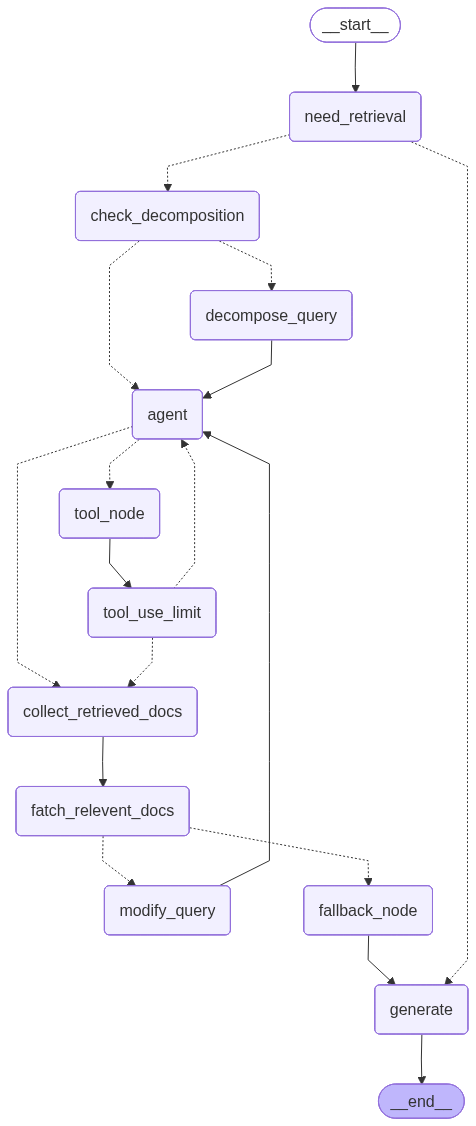

In [97]:
workflow

In [105]:
query_1 = (
    "Impact of EVs on the oil industry, "
    "and what is the current price of oil in US dollars for Brent Crude"
)

result = workflow.invoke({
    "query": query_1,
    "messages": []
})

In [106]:
result['messages']

[AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 525, 'total_tokens': 592, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_81339dda16', 'id': 'chatcmpl-DgPVoVz42SejmNI2kjyyYVSr97Wpn', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e34ad-0858-72c0-a664-f9e93f90a1c8-0', tool_calls=[{'name': 'vector_store_search', 'args': {'query': 'impact of electric vehicles on the oil industry', 'k': 5}, 'id': 'call_8OYzpAqqpHkIYNd9SkeDinw4', 'type': 'tool_call'}, {'name': 'web_search', 'args': {'query': 'current price of Brent Crude oil USD', 'k': 3}, 'id': 'call_JFC5FiHFipqa08u5PsVr2n3F', 'type': 'tool_call'}], invalid_too

In [107]:
print(result['messages'][-1].content)



## Vector Store Results

Brent rose to 109.26 USD/Bbl on May 15, 2026, up 3.35% from the previous day. Over the past month, Brent's price has risen 9.93%, and is up 67.04% compared

NY Mercantile - Delayed Quote • USD. Brent Crude Oil Last Day Financ (BZ=F). 109.26 +3.54 (+3.35%). MARKET_TIME_NOTICE_CLOSED_SHORT. Chart Range Bar.

Crude Oil Brent (OIL) price today is $69.69, with a 24-hour trading volume of $468.93 and as such Crude Oil Brent (OIL) has a market cap of --, giving it a


In [108]:
result['retrieved_docs']

[Document(id='4ab2c9a3-0d5f-41e0-8ec3-97fc3c9896a9', metadata={'source': 'D:\\LangGraph_Revision_Material\\evs_oil_price_shock.pdf', 'total_pages': 15, 'creationdate': '2026-04-18T21:49:03+05:00', 'trapped': '/False', 'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'keywords': '', 'page_label': '1', 'moddate': '2026-04-18T21:49:03+05:00', 'page': 0, 'author': '(anonymous)', 'title': '(anonymous)', 'subject': '(unspecified)'}, page_content='Will EVs Dampen the Oil Price\n Shock?\nElectric Vehicles, Oil Demand Destruction, and the Future of Energy Price\n Volatility\n Version 1.0   |   April 2026\n Technical Reference Document'),
 Document(id='b2db646a-d997-42de-a518-1e172626d89c', metadata={'source': 'D:\\LangGraph_Revision_Material\\evs_oil_price_shock.pdf', 'total_pages': 15, 'creationdate': '2026-04-18T21:49:03+05:00', 'producer': 'ReportLab PDF Library - (opensource)', 'author': '(anonymous)', 'page': 8, 'subject': '(unspecified)', 'page_label': '9', 

In [109]:
result

{'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 525, 'total_tokens': 592, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_81339dda16', 'id': 'chatcmpl-DgPVoVz42SejmNI2kjyyYVSr97Wpn', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e34ad-0858-72c0-a664-f9e93f90a1c8-0', tool_calls=[{'name': 'vector_store_search', 'args': {'query': 'impact of electric vehicles on the oil industry', 'k': 5}, 'id': 'call_8OYzpAqqpHkIYNd9SkeDinw4', 'type': 'tool_call'}, {'name': 'web_search', 'args': {'query': 'current price of Brent Crude oil USD', 'k': 3}, 'id': 'call_JFC5FiHFipqa08u5PsVr2n3F', 'type': 'tool_call'}]

In [110]:
print(result['answer'])

The impact of electric vehicles (EVs) on the oil industry is driven by the adoption of EVs displacing oil demand, particularly in the transportation sector, which accounts for approximately 57 percent of global oil demand. The significant factor influencing EV adoption is the cost of lithium-ion battery packs, which has drastically reduced over the years. Industry analysts expect battery costs to reach levels necessary for widespread EV adoption by 2027-2028.

As for the current price of oil, Brent Crude is priced at $109.26 per barrel as of May 15, 2026.
